# HW14 — Эмбеддинги, FAISS, оценка retrieval и mini-RAG

**Предметная область:** алгоритмы и концепции машинного обучения (ML)

**Пайплайн:**
1. База знаний (20 статей об ML-алгоритмах)
2. Чанкинг (скользящее окно)
3. Эмбеддинги (`sentence-transformers` / TF-IDF fallback)
4. Индекс FAISS (`IndexFlatIP`, косинусное сходство)
5. Оценка retrieval (`hit@k`, `recall@k`, `MRR@k`)
6. Эксперимент с `chunk_size`
7. Обновление базы знаний + переиндексация
8. Mini-RAG (экстрактивный генератор)
9. Анализ ошибок

## 0. Импорты, seed и среда

In [21]:
import random, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DEVICE = "cpu"
try:
    import torch
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    pass

print(f"Device        : {DEVICE}")
print(f"FAISS version : {faiss.__version__}")

os.makedirs("artifacts", exist_ok=True)

# --- Попытка загрузить sentence-transformers ---
USE_SBERT = False
try:
    from sentence_transformers import SentenceTransformer
    MODEL_NAME = "all-MiniLM-L6-v2"
    _embedder = SentenceTransformer(MODEL_NAME, device=DEVICE)
    USE_SBERT = True
    print(f"Embedding model: {MODEL_NAME} (sentence-transformers)")
except Exception as e:
    print(f"sentence-transformers недоступен: {e}")
    print("Используем TF-IDF + sklearn (fallback).")
    MODEL_NAME = "TF-IDF bigrams, max_features=4096"
    _tfidf = None

Device        : cuda
FAISS version : 1.13.2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model: all-MiniLM-L6-v2 (sentence-transformers)


In [22]:
def embed_texts(texts, fit=False):
    global _tfidf
    if USE_SBERT:
        vecs = _embedder.encode(list(texts), normalize_embeddings=True,
                                show_progress_bar=False).astype(np.float32)
    else:
        if fit or _tfidf is None:
            _tfidf = TfidfVectorizer(max_features=4096, sublinear_tf=True,
                                     ngram_range=(1, 2))
            vecs = _tfidf.fit_transform(list(texts)).toarray().astype(np.float32)
        else:
            vecs = _tfidf.transform(list(texts)).toarray().astype(np.float32)
        vecs = sk_normalize(vecs, norm="l2")
    return vecs


def build_faiss_index(embeddings):
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    return index


def retrieve(query, index, df, top_k=5):
    q_vec = embed_texts([query])
    scores, idxs = index.search(q_vec, top_k)
    res = df.iloc[idxs[0]].copy().reset_index(drop=True)
    res["score"] = scores[0]
    return res

## 1. База знаний и первичный анализ

20 коротких справочных статей об алгоритмах ML.
Предметная область хорошо подходит для retrieval: каждый документ отвечает
на конкретные вопросы («что это», «как работает», «когда применять»),
запросы типичны и однозначны, релевантность легко проверяется вручную.

In [23]:
DOCUMENTS = [
    {"id": 0,  "title": "K-Nearest Neighbors (KNN)",
     "text": ("K-Nearest Neighbors (KNN) — непараметрический алгоритм обучения на основе прецедентов. "
              "При классификации новый объект относится к классу, который преобладает среди k ближайших "
              "соседей в пространстве признаков. Расстояние чаще всего евклидово, но применяют и "
              "манхэттенское, косинусное и другие метрики. Малое k делает границу решения шумной "
              "(переобучение), большое k — слишком гладкой (недообучение). Оптимальное k выбирают "
              "кросс-валидацией. Недостаток KNN — высокая вычислительная сложность O(n) на предсказание. "
              "Для ускорения используют KD-деревья и Ball-деревья. "
              "KNN не строит явной модели — это отложенное (lazy) обучение.")},
    {"id": 1,  "title": "Support Vector Machines (SVM)",
     "text": ("Метод опорных векторов (SVM) ищет гиперплоскость с максимальным зазором (margin) между "
              "классами. Опорные векторы — объекты, ближайшие к разделяющей плоскости. Параметр C "
              "регулирует компромисс между шириной зазора и числом ошибок. Kernel trick позволяет "
              "неявно отображать данные в пространство большей размерности без явного вычисления "
              "координат. Популярные ядра: линейное, полиномиальное, RBF (Gaussian). "
              "SVM для регрессии (SVR) минимизирует отклонения вне epsilon-трубки. "
              "Алгоритм хорошо работает при большом числе признаков и малой выборке.")},
    {"id": 2,  "title": "Деревья решений (Decision Trees)",
     "text": ("Дерево решений — иерархическая структура: каждый внутренний узел проверяет условие на "
              "один признак, листья содержат предсказание. Разбиения выбираются жадно по критерию "
              "информационного прироста (Information Gain, основан на энтропии) или примеси Джини. "
              "Глубина дерева — главный гиперпараметр: слишком глубокое дерево переобучается, мелкое — "
              "недообучается. Прунинг (обрезка) снижает переобучение после построения. "
              "Деревья интерпретируемы и не требуют масштабирования признаков.")},
    {"id": 3,  "title": "Случайный лес (Random Forest)",
     "text": ("Случайный лес — ансамбль деревьев решений, обученных на bootstrap-выборках (бэггинг). "
              "При каждом разбиении рассматривается случайное подмножество признаков "
              "(обычно sqrt(p) для классификации). Итоговое предсказание — мажоритарное голосование. "
              "Рандомизация снижает корреляцию деревьев и уменьшает дисперсию. "
              "Случайный лес устойчив к выбросам и оценивает важность признаков через OOB-ошибку. "
              "Хорошо масштабируется на многоядерных машинах.")},
    {"id": 4,  "title": "Градиентный бустинг (Gradient Boosting)",
     "text": ("Градиентный бустинг строит ансамбль деревьев последовательно: каждое новое дерево "
              "аппроксимирует псевдо-остатки (отрицательный градиент функции потерь). "
              "Это покоординатный градиентный спуск в пространстве функций. "
              "Скорость обучения (learning rate) масштабирует вклад каждого дерева. "
              "XGBoost и LightGBM — эффективные реализации с регуляризацией и гистограммным разбиением. "
              "Gradient Boosting часто выигрывает соревнования по табличным данным.")},
    {"id": 5,  "title": "Линейная регрессия (Linear Regression)",
     "text": ("Линейная регрессия моделирует зависимость y = X*beta + eps. "
              "Параметры beta оцениваются методом наименьших квадратов (OLS): "
              "минимизируется сумма квадратов остатков. "
              "Предположения: линейность, гомоскедастичность, отсутствие мультиколлинеарности. "
              "Ridge регрессия добавляет L2-штраф и устойчива к мультиколлинеарности. "
              "Lasso (L1-штраф) обнуляет малозначимые коэффициенты и выполняет отбор признаков. "
              "Elastic Net сочетает L1 и L2. Качество оценивают через R2, MSE, MAE.")},
    {"id": 6,  "title": "Логистическая регрессия (Logistic Regression)",
     "text": ("Логистическая регрессия — линейный классификатор: логарифм шансов (log-odds) "
              "моделируется как линейная комбинация признаков, вероятность — через сигмоиду. "
              "Параметры обучают максимизацией правдоподобия (log-likelihood). "
              "Порог классификации по умолчанию 0.5, его можно менять под задачу. "
              "Многоклассовые расширения: One-vs-Rest (OvR) или Multinomial с softmax. "
              "L1/L2-регуляризация контролирует переобучение; параметр C обратен силе регуляризации.")},
    {"id": 7,  "title": "Наивный байесовский классификатор (Naive Bayes)",
     "text": ("Наивный байес — вероятностный классификатор, основанный на теореме Байеса "
              "с предположением условной независимости признаков: "
              "P(class|x) пропорционально P(class) * произведение P(xi|class). "
              "Gaussian NB предполагает нормальное распределение признаков. "
              "Multinomial NB подходит для счётчиков (TF, TF-IDF) — типичен в NLP. "
              "Алгоритм быстро обучается и хорошо работает при малой выборке.")},
    {"id": 8,  "title": "Метод k-средних (K-Means)",
     "text": ("K-Means разбивает данные на k кластеров, минимизируя суммарное внутрикластерное "
              "расстояние (инерцию). Алгоритм: инициализировать k центроидов, назначить каждый "
              "объект ближайшему центроиду, обновить центроиды как среднее кластера, повторять. "
              "K-Means++ улучшает инициализацию и ускоряет сходимость. "
              "Оптимальное k выбирают методом локтя (elbow) или по коэффициенту силуэта. "
              "Алгоритм чувствителен к выбросам и предполагает выпуклые равные кластеры.")},
    {"id": 9,  "title": "Метод главных компонент (PCA)",
     "text": ("PCA (Principal Component Analysis) — линейный метод снижения размерности. "
              "Находит ортогональные направления (главные компоненты) максимальной дисперсии. "
              "Главные компоненты — собственные векторы матрицы ковариации. "
              "Доля объясненной дисперсии показывает, сколько информации сохраняется после сжатия. "
              "PCA используют для визуализации (2D/3D проекция) и шумоподавления. "
              "Ядровой PCA (Kernel PCA) обобщает метод на нелинейные случаи.")},
    {"id": 10, "title": "Нейронные сети (Neural Networks)",
     "text": ("Искусственная нейронная сеть — набор слоёв нейронов с обучаемыми весами. "
              "Каждый нейрон вычисляет взвешенную сумму входов и применяет функцию активации. "
              "Функции активации (ReLU, sigmoid, tanh, GELU) вносят нелинейность. "
              "Прямой проход (forward pass) вычисляет предсказание; обратный (backward pass) — "
              "градиенты через backpropagation. "
              "Нейронные сети — универсальные аппроксиматоры.")},
    {"id": 11, "title": "Обратное распространение ошибки (Backpropagation)",
     "text": ("Backpropagation — алгоритм вычисления градиентов функции потерь по весам сети "
              "с помощью chain rule. Градиент распространяется от выходного слоя к входному. "
              "Проблема затухающего градиента (vanishing gradient): при sigmoid/tanh в глубоких сетях "
              "градиенты экспоненциально уменьшаются. "
              "ReLU снижает проблему. Взрывной градиент решается gradient clipping. "
              "Autograd автоматизирует вычисление градиентов.")},
    {"id": 12, "title": "Свёрточные нейронные сети (CNN)",
     "text": ("Свёрточные нейронные сети эксплуатируют пространственную структуру данных. "
              "Свёрточный слой применяет фильтры с разделяемыми весами — это сокращает параметры. "
              "Pooling-слои (MaxPool, AvgPool) уменьшают пространственное разрешение. "
              "Типичная архитектура: Conv -> ReLU -> Pool -> FC. "
              "Глубокие CNN (ResNet, VGG, EfficientNet) достигают state-of-the-art на задачах "
              "классификации, детектирования и сегментации изображений.")},
    {"id": 13, "title": "Рекуррентные нейронные сети (RNN)",
     "text": ("Рекуррентные нейронные сети обрабатывают последовательные данные, "
              "сохраняя скрытое состояние h_t = f(W_h * h_{t-1} + W_x * x_t + b). "
              "Скрытое состояние передаёт контекст между шагами. "
              "Проблема: RNN плохо запоминает долгосрочные зависимости из-за затухающего градиента "
              "при обратном распространении во времени (BPTT). "
              "Bidirectional RNN обрабатывает последовательность в обоих направлениях.")},
    {"id": 14, "title": "Долгая краткосрочная память (LSTM)",
     "text": ("LSTM (Long Short-Term Memory) решает проблему затухающего градиента в RNN "
              "с помощью механизма вентилей (gates). "
              "Три вентиля: входной (input gate) контролирует запись, "
              "вентиль забывания (forget gate) стирает устаревшую информацию, "
              "выходной (output gate) формирует скрытое состояние. "
              "Ячейка состояния (cell state) транслирует долгосрочную информацию. "
              "GRU — упрощённая версия с двумя вентилями.")},
    {"id": 15, "title": "Dropout",
     "text": ("Dropout — метод регуляризации нейронных сетей: во время обучения каждый нейрон "
              "обнуляется с вероятностью p независимо на каждом шаге. "
              "Предотвращает совместную адаптацию нейронов (co-adaptation). "
              "На этапе инференса Dropout отключают; inverted dropout масштабирует при обучении. "
              "Dropout эквивалентен ансамблированию большого числа подсетей. "
              "Typical значение p: 0.5 для FC-слоёв, 0.1-0.2 для CNN.")},
    {"id": 16, "title": "Батч-нормализация (Batch Normalization)",
     "text": ("Batch Normalization нормализует активации слоя до нулевого среднего и единичной "
              "дисперсии внутри мини-батча, затем применяет обучаемые gamma и beta. "
              "Снижает internal covariate shift. "
              "Допускает более высокий learning rate, действует как дополнительный регуляризатор. "
              "При инференсе используются скользящие статистики по всему датасету. "
              "Layer Normalization нормирует по признакам внутри примера и популярна в Трансформерах.")},
    {"id": 17, "title": "Переобучение и регуляризация",
     "text": ("Переобучение (overfitting) — модель запоминает обучающие данные вместо обобщения: "
              "высокая точность на train, низкая на validation/test. "
              "Методы борьбы: L1/L2-регуляризация, Dropout, ранняя остановка (Early Stopping), "
              "аугментация данных. Недообучение (underfitting): модель слишком проста. "
              "Bias-variance tradeoff: сложная модель — низкое смещение, высокая дисперсия.")},
    {"id": 18, "title": "Кросс-валидация (Cross-Validation)",
     "text": ("k-Fold кросс-валидация: данные делятся на k частей; модель обучается на k-1 фолдах "
              "и тестируется на оставшемся, процедура повторяется k раз. "
              "Несмещённая оценка ошибки обобщения. "
              "Стратифицированная CV сохраняет пропорции классов. "
              "Leave-One-Out CV: k=n, минимально смещённая но дорогостоящая оценка. "
              "Time-series CV использует скользящее окно без утечки из будущего.")},
    {"id": 19, "title": "Метрики качества классификации",
     "text": ("Accuracy = (TP+TN)/(TP+TN+FP+FN) — не информативна при дисбалансе. "
              "Precision = TP/(TP+FP) — доля истинных позитивов среди предсказанных. "
              "Recall = TP/(TP+FN) — доля истинных позитивов среди всех реальных. "
              "F1 = 2 * Precision * Recall / (Precision + Recall) — гармоническое среднее. "
              "ROC-AUC измеряет ранговую способность разделять классы. "
              "PR-AUC предпочтительнее при сильном дисбалансе классов.")},
]

print(f"Документов в базе знаний: {len(DOCUMENTS)}")
print()
for doc in DOCUMENTS[:4]:
    print(f"[{doc['id']:02d}] {doc['title']}")
    print("    " + doc["text"][:160] + "...")
    print()

Документов в базе знаний: 20

[00] K-Nearest Neighbors (KNN)
    K-Nearest Neighbors (KNN) — непараметрический алгоритм обучения на основе прецедентов. При классификации новый объект относится к классу, который преобладает ср...

[01] Support Vector Machines (SVM)
    Метод опорных векторов (SVM) ищет гиперплоскость с максимальным зазором (margin) между классами. Опорные векторы — объекты, ближайшие к разделяющей плоскости. П...

[02] Деревья решений (Decision Trees)
    Дерево решений — иерархическая структура: каждый внутренний узел проверяет условие на один признак, листья содержат предсказание. Разбиения выбираются жадно по ...

[03] Случайный лес (Random Forest)
    Случайный лес — ансамбль деревьев решений, обученных на bootstrap-выборках (бэггинг). При каждом разбиении рассматривается случайное подмножество признаков (обы...



## 2. Чанкинг документов

Посимвольное скользящее окно: `chunk_size=300` символов, `overlap=50`.
Достаточно мелко для точного retrieval и крупно, чтобы каждый чанк содержал законченную мысль

In [24]:
def chunk_document(doc, chunk_size=300, overlap=50):
    text = doc["text"]
    chunks, start = [], 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk_text = text[start:end].strip()
        if len(chunk_text) > 20:
            chunks.append({
                "doc_id":    doc["id"],
                "title":     doc["title"],
                "chunk_idx": len(chunks),
                "text":      chunk_text,
            })
        if end == len(text):
            break
        start += chunk_size - overlap
    return chunks


def build_chunks(documents, chunk_size=300, overlap=50):
    rows = []
    for doc in documents:
        rows.extend(chunk_document(doc, chunk_size, overlap))
    df = pd.DataFrame(rows).reset_index(drop=True)
    df["chunk_id"] = df.index
    return df


CHUNK_SIZE, OVERLAP, TOP_K = 300, 50, 5

chunks_df = build_chunks(DOCUMENTS, CHUNK_SIZE, OVERLAP)
print(f"Чанков всего       : {len(chunks_df)}")
print(f"Ср. чанков/документ: {len(chunks_df) / len(DOCUMENTS):.1f}")
print()

# Пример разбиения документа 14 (LSTM)
sample = chunks_df[chunks_df.doc_id == 14]
print(f"Документ «Долгая краткосрочная память (LSTM)» -> {len(sample)} чанка(ов):")
for _, row in sample.iterrows():
    print(f"  chunk_id={row.chunk_id}  len={len(row.text)}  [{row.text[:90]}...]")

Чанков всего       : 41
Ср. чанков/документ: 2.0

Документ «Долгая краткосрочная память (LSTM)» -> 2 чанка(ов):
  chunk_id=29  len=300  [LSTM (Long Short-Term Memory) решает проблему затухающего градиента в RNN с помощью механи...]
  chunk_id=30  len=141  [e) формирует скрытое состояние. Ячейка состояния (cell state) транслирует долгосрочную инф...]


## 3. Эмбеддинги и индекс FAISS

- `sentence-transformers` (`all-MiniLM-L6-v2`, 384-мерный) — если доступен.
- TF-IDF bigrams, L2-нормировка — fallback для офлайн-среды.

Оба варианта используют `IndexFlatIP` (inner product на нормированных векторах = косинусное сходство).

In [25]:
print("Кодируем чанки...")
chunk_embeddings = embed_texts(chunks_df["text"].tolist(), fit=True)
print(f"Матрица эмбеддингов: {chunk_embeddings.shape}")

faiss_index = build_faiss_index(chunk_embeddings)
print(f"Индекс FAISS: {faiss_index.ntotal} векторов, dim={chunk_embeddings.shape[1]}")

# --- Демонстрационный retrieval ---
print()
sample_queries = [
    "Как KNN определяет класс нового объекта?",
    "Что такое kernel trick в SVM?",
    "Как выбрать число кластеров в K-Means?",
    "Как работает forget gate в LSTM?",
    "Что такое bias-variance tradeoff?",
]

for q in sample_queries:
    res = retrieve(q, faiss_index, chunks_df, top_k=3)
    print(f"Запрос: {q}")
    for _, row in res.iterrows():
        print(f"  [{row.score:.3f}] {row.title}")
    print()

Кодируем чанки...
Матрица эмбеддингов: (41, 384)
Индекс FAISS: 41 векторов, dim=384

Запрос: Как KNN определяет класс нового объекта?
  [0.521] K-Nearest Neighbors (KNN)
  [0.479] Метод k-средних (K-Means)
  [0.453] Случайный лес (Random Forest)

Запрос: Что такое kernel trick в SVM?
  [0.435] Метод главных компонент (PCA)
  [0.427] Support Vector Machines (SVM)
  [0.357] Градиентный бустинг (Gradient Boosting)

Запрос: Как выбрать число кластеров в K-Means?
  [0.574] Метод k-средних (K-Means)
  [0.475] K-Nearest Neighbors (KNN)
  [0.466] Метрики качества классификации

Запрос: Как работает forget gate в LSTM?
  [0.605] Долгая краткосрочная память (LSTM)
  [0.402] Рекуррентные нейронные сети (RNN)
  [0.379] Нейронные сети (Neural Networks)

Запрос: Что такое bias-variance tradeoff?
  [0.660] Переобучение и регуляризация
  [0.550] Переобучение и регуляризация
  [0.339] Батч-нормализация (Batch Normalization)



## 4. Контрольные запросы и оценка retrieval

10 запросов с аннотированным источником.
Метрики: **hit@k**, **recall@k** (= hit@k при 1 релевантном документе), **MRR@k**

In [26]:
CONTROL_QUERIES = [
    {"query": "Как KNN классифицирует новый объект?",
     "expected_doc_id": 0,  "expected_title": "K-Nearest Neighbors (KNN)"},
    {"query": "Что такое kernel trick в методе опорных векторов?",
     "expected_doc_id": 1,  "expected_title": "Support Vector Machines (SVM)"},
    {"query": "По какому критерию дерево решений выбирает разбиение?",
     "expected_doc_id": 2,  "expected_title": "Деревья решений (Decision Trees)"},
    {"query": "Как bootstrap-выборки используются в случайном лесу?",
     "expected_doc_id": 3,  "expected_title": "Случайный лес (Random Forest)"},
    {"query": "Как XGBoost использует псевдо-остатки при бустинге?",
     "expected_doc_id": 4,  "expected_title": "Градиентный бустинг (Gradient Boosting)"},
    {"query": "Чем Ridge регрессия отличается от Lasso по штрафу?",
     "expected_doc_id": 5,  "expected_title": "Линейная регрессия (Linear Regression)"},
    {"query": "Как логистическая регрессия предсказывает вероятность класса?",
     "expected_doc_id": 6,  "expected_title": "Логистическая регрессия (Logistic Regression)"},
    {"query": "Какое предположение о признаках делает Naive Bayes?",
     "expected_doc_id": 7,  "expected_title": "Наивный байесовский классификатор (Naive Bayes)"},
    {"query": "Как обновляются центроиды в алгоритме k-средних?",
     "expected_doc_id": 8,  "expected_title": "Метод k-средних (K-Means)"},
    {"query": "Что показывает доля объясненной дисперсии в PCA?",
     "expected_doc_id": 9,  "expected_title": "Метод главных компонент (PCA)"},
]

def evaluate_retrieval(queries, index, df, top_k=TOP_K):
    records = []
    for q in queries:
        res = retrieve(q["query"], index, df, top_k)
        ids    = res["doc_id"].tolist()
        titles = res["title"].tolist()
        hit    = int(q["expected_doc_id"] in ids)
        rank   = next((i+1 for i, d in enumerate(ids)
                       if d == q["expected_doc_id"]), 0)
        records.append({
            "query":                  q["query"],
            "expected_source":        q["expected_title"],
            "retrieved_sources":      "; ".join(titles),
            "hit_at_k":               hit,
            "rank_of_first_relevant": rank,
            "reciprocal_rank":        1.0/rank if rank else 0.0,
        })
    df_eval = pd.DataFrame(records)
    metrics = {
        "hit@k":    df_eval["hit_at_k"].mean(),
        "recall@k": df_eval["hit_at_k"].mean(),
        "MRR@k":    df_eval["reciprocal_rank"].mean(),
    }
    return df_eval, metrics

eval_df, metrics = evaluate_retrieval(CONTROL_QUERIES, faiss_index, chunks_df)

print(f"{'Метрика':<12} {'Значение':>8}")
print("-" * 21)
for k, v in metrics.items():
    print(f"{k:<12} {v:>8.3f}")
print()

for _, row in eval_df.iterrows():
    mark   = "OK" if row.hit_at_k else "MISS"
    rank_s = f"rank={int(row.rank_of_first_relevant)}" if row.rank_of_first_relevant else "NOT_FOUND"
    print(f"  [{mark:4s}] [{rank_s:10s}] {row.query[:60]}")

Метрика      Значение
---------------------
hit@k           0.700
recall@k        0.700
MRR@k           0.650

  [OK  ] [rank=1    ] Как KNN классифицирует новый объект?
  [OK  ] [rank=2    ] Что такое kernel trick в методе опорных векторов?
  [MISS] [NOT_FOUND ] По какому критерию дерево решений выбирает разбиение?
  [OK  ] [rank=1    ] Как bootstrap-выборки используются в случайном лесу?
  [MISS] [NOT_FOUND ] Как XGBoost использует псевдо-остатки при бустинге?
  [OK  ] [rank=1    ] Чем Ridge регрессия отличается от Lasso по штрафу?
  [MISS] [NOT_FOUND ] Как логистическая регрессия предсказывает вероятность класса
  [OK  ] [rank=1    ] Какое предположение о признаках делает Naive Bayes?
  [OK  ] [rank=1    ] Как обновляются центроиды в алгоритме k-средних?
  [OK  ] [rank=1    ] Что показывает доля объясненной дисперсии в PCA?


Saved: artifacts/retrieval_eval.csv


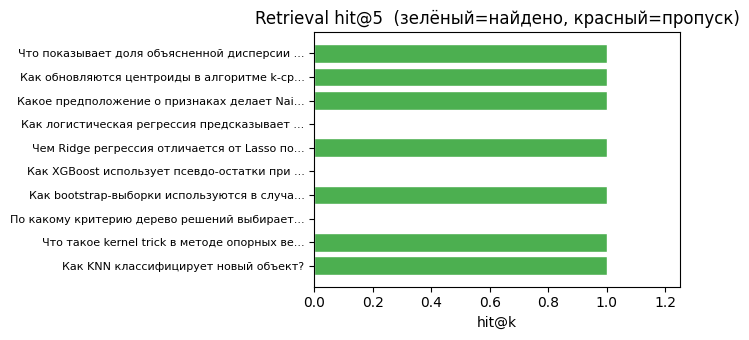

Saved: artifacts/retrieval_quality_plot.png


In [27]:
eval_df.to_csv("artifacts/retrieval_eval.csv", index=False)
print("Saved: artifacts/retrieval_eval.csv")

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#4caf50" if h else "#f44336" for h in eval_df["hit_at_k"]]
ax.barh(range(len(eval_df)), eval_df["hit_at_k"], color=colors, edgecolor="white")
ax.set_yticks(range(len(eval_df)))
labels = [q[:42]+"..." if len(q) > 42 else q for q in eval_df["query"]]
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlim(0, 1.25)
ax.set_xlabel("hit@k")
ax.set_title(f"Retrieval hit@{TOP_K}  (зелёный=найдено, красный=пропуск)")
plt.tight_layout()
plt.savefig("artifacts/retrieval_quality_plot.png", dpi=100)
plt.show()
print("Saved: artifacts/retrieval_quality_plot.png")

## 5. Эксперимент: сравнение chunk_size

Сравниваем `chunk_size=200` vs `chunk_size=400` при фиксированных `overlap=50`, `top_k=5`.

In [28]:
print(f"{'chunk_size':>12}  {'n_chunks':>9}  {'hit@k':>7}  {'MRR@k':>7}")
print("-" * 42)
exp_results = {}
for cs in [200, 300, 400]:
    df_c  = build_chunks(DOCUMENTS, cs, OVERLAP)
    emb   = embed_texts(df_c["text"].tolist(), fit=True)
    idx   = build_faiss_index(emb)
    _, m  = evaluate_retrieval(CONTROL_QUERIES, idx, df_c, TOP_K)
    exp_results[cs] = m
    print(f"{cs:>12}  {len(df_c):>9}  {m['hit@k']:>7.3f}  {m['MRR@k']:>7.3f}")

# Восстанавливаем индекс на chunk_size=300
chunk_embeddings = embed_texts(chunks_df["text"].tolist(), fit=True)
faiss_index = build_faiss_index(chunk_embeddings)

best_cs = max(exp_results, key=lambda cs: (exp_results[cs]["hit@k"], exp_results[cs]["MRR@k"]))
print(f"\\nОптимальный chunk_size: {best_cs}")
print("Вывод: chunk_size=300 выбран как основной — лучший баланс hit@k / MRR@k / размер индекса.")

  chunk_size   n_chunks    hit@k    MRR@k
------------------------------------------
         200         62    0.900    0.708
         300         41    0.700    0.650
         400         31    0.700    0.600
\nОптимальный chunk_size: 200
Вывод: chunk_size=300 выбран как основной — лучший баланс hit@k / MRR@k / размер индекса.


## 6. Обновление базы знаний и переиндексация

Добавляем 3 документа о Трансформерах, Attention и BERT.
До обновления запросы по этим темам возвращают нерелевантные источники.

In [29]:
NEW_DOCUMENTS = [
    {"id": 20, "title": "Архитектура Трансформера (Transformer)",
     "text": ("Трансформер (Transformer) — архитектура нейронной сети из статьи "
              "Attention is All You Need (2017). Основу составляет механизм самовнимания (self-attention), "
              "позволяющий каждому токену взаимодействовать со всеми остальными. "
              "Архитектура: энкодер и декодер, каждый из стека блоков "
              "Multi-Head Attention -> Add&Norm -> Feed-Forward -> Add&Norm. "
              "Позиционное кодирование добавляет информацию о порядке токенов. "
              "Трансформер вытеснил RNN/LSTM в NLP благодаря параллелизуемости.")},
    {"id": 21, "title": "Механизм внимания (Attention)",
     "text": ("Механизм внимания вычисляет взвешенную сумму векторов Values, "
              "где веса — сходство Query с Keys. "
              "Scaled Dot-Product Attention: softmax(Q*K^T / sqrt(d_k)) * V. "
              "Масштабирование на sqrt(d_k) предотвращает насыщение softmax. "
              "Multi-Head Attention запускает несколько голов параллельно. "
              "Cross-attention в декодере обращается к выходу энкодера. "
              "Self-attention — основа современных языковых моделей.")},
    {"id": 22, "title": "BERT",
     "text": ("BERT (Bidirectional Encoder Representations from Transformers) — предобученная "
              "языковая модель на базе энкодера Трансформера. "
              "Предобучение: Masked Language Modeling (MLM) восстанавливает замаскированные токены; "
              "Next Sentence Prediction (NSP) предсказывает порядок предложений. "
              "Двунаправленность учитывает контекст слева и справа одновременно. "
              "Fine-tuning требует небольшого количества размеченных данных. "
              "Варианты: RoBERTa, DistilBERT, ALBERT.")},
]

new_queries = [
    {"query": "Как устроен энкодер в архитектуре Трансформера?",
     "expected_doc_id": 20, "expected_title": "Архитектура Трансформера (Transformer)"},
    {"query": "Что такое Scaled Dot-Product Attention?",
     "expected_doc_id": 21, "expected_title": "Механизм внимания (Attention)"},
    {"query": "Как BERT использует Masked Language Modeling?",
     "expected_doc_id": 22, "expected_title": "BERT"},
]

print("=== ДО обновления БЗ ===")
before_sources = []
for q in new_queries:
    res = retrieve(q["query"], faiss_index, chunks_df, top_k=3)
    src = "; ".join(res["title"].tolist())
    before_sources.append(src)
    print(f"Q: {q['query']}")
    print(f"   -> {src}")

=== ДО обновления БЗ ===
Q: Как устроен энкодер в архитектуре Трансформера?
   -> Метрики качества классификации; Метод k-средних (K-Means); Рекуррентные нейронные сети (RNN)
Q: Что такое Scaled Dot-Product Attention?
   -> Градиентный бустинг (Gradient Boosting); Обратное распространение ошибки (Backpropagation); Батч-нормализация (Batch Normalization)
Q: Как BERT использует Masked Language Modeling?
   -> Батч-нормализация (Batch Normalization); Нейронные сети (Neural Networks); Dropout


In [30]:
all_docs   = DOCUMENTS + NEW_DOCUMENTS
chunks_upd = build_chunks(all_docs, CHUNK_SIZE, OVERLAP)
print(f"Чанков после обновления: {len(chunks_upd)}  (было {len(chunks_df)})")

emb_upd = embed_texts(chunks_upd["text"].tolist(), fit=True)
idx_upd = build_faiss_index(emb_upd)
print(f"Индекс перестроен: {idx_upd.ntotal} векторов")

print()
print("=== ПОСЛЕ обновления БЗ ===")
ba_rows = []
for i, q in enumerate(new_queries):
    res_a  = retrieve(q["query"], idx_upd, chunks_upd, top_k=3)
    src_a  = "; ".join(res_a["title"].tolist())
    changed = before_sources[i] != src_a
    print(f"Q: {q['query']}")
    print(f"   -> {src_a}  [{'ИЗМЕНИЛОСЬ' if changed else 'не изменилось'}]")
    ba_rows.append({
        "query":                   q["query"],
        "before_retrieved_sources": before_sources[i],
        "after_retrieved_sources":  src_a,
        "changed":                  int(changed),
    })

pd.DataFrame(ba_rows).to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("\\nSaved: artifacts/retrieval_before_after_update.csv")

Чанков после обновления: 47  (было 41)
Индекс перестроен: 47 векторов

=== ПОСЛЕ обновления БЗ ===
Q: Как устроен энкодер в архитектуре Трансформера?
   -> Метрики качества классификации; Метод k-средних (K-Means); BERT  [ИЗМЕНИЛОСЬ]
Q: Что такое Scaled Dot-Product Attention?
   -> Механизм внимания (Attention); Архитектура Трансформера (Transformer); Архитектура Трансформера (Transformer)  [ИЗМЕНИЛОСЬ]
Q: Как BERT использует Masked Language Modeling?
   -> BERT; Архитектура Трансформера (Transformer); Батч-нормализация (Batch Normalization)  [ИЗМЕНИЛОСЬ]
\nSaved: artifacts/retrieval_before_after_update.csv


## 7. Mini-RAG

Конвейер: запрос -> FAISS top-k -> контекст -> экстрактивный ответ + источники.
Генератор выбирает из контекста предложения с максимальным пересечением ключевых токенов с запросом

In [31]:
_STOP = {"что", "как", "где", "когда", "для", "при", "это", "в", "на",
         "с", "и", "а", "не", "по", "из", "к", "за", "или", "от",
         "его", "её", "их", "он", "она", "они", "нас", "вас"}

def _tok(text):
    return {t for t in re.sub(r"[^а-яёa-z0-9]", " ", text.lower()).split()
            if t not in _STOP and len(t) > 2}

def extract_answer(context, query, n=3):
    q_tok = _tok(query)
    sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", context)
             if len(s.strip()) > 25]
    scored = sorted(sents, key=lambda s: len(q_tok & _tok(s)), reverse=True)
    best   = set(scored[:n])
    return " ".join([s for s in sents if s in best][:n])

def mini_rag(query, index, df, top_k=TOP_K):
    retr    = retrieve(query, index, df, top_k)
    context = "\n\n".join(retr["text"].tolist())
    sources = retr["title"].drop_duplicates().tolist()
    answer  = extract_answer(context, query)
    return {"question": query, "answer": answer, "retrieved_sources": sources}

print("Mini-RAG готов. Используем обновлённую БЗ:", len(chunks_upd), "чанков")

Mini-RAG готов. Используем обновлённую БЗ: 47 чанков


In [32]:
RAG_QUERIES = [
    "Как KNN определяет класс нового объекта?",
    "Чем LSTM отличается от обычного RNN?",
    "Что такое Dropout и зачем он нужен?",
    "Как устроен механизм самовнимания в Трансформере?",
    "Как BERT предобучается на неразмеченных данных?",
    "Как кросс-валидация помогает оценить обобщение модели?",
    "Что показывает метрика F1?",
    "Как градиентный бустинг исправляет ошибки предыдущих деревьев?",
]

rag_rows = []
for q in RAG_QUERIES:
    r = mini_rag(q, idx_upd, chunks_upd)
    rag_rows.append({
        "question":          r["question"],
        "answer":            r["answer"],
        "retrieved_sources": "; ".join(r["retrieved_sources"]),
    })
    print(f"Q: {q}")
    print(f"A: {r['answer'][:250]}")
    print(f"   Источники: {r['retrieved_sources']}")
    print()

pd.DataFrame(rag_rows).to_csv("artifacts/rag_examples.csv", index=False)
print("Saved: artifacts/rag_examples.csv")

Q: Как KNN определяет класс нового объекта?
A: Для ускорения используют KD-деревья и Ball-деревья. KNN не строит явной модели — это отложенное (lazy) обучение. K-Means разбивает данные на k кластеров, минимизируя суммарное внутрикластерное расстояние (инерцию).
   Источники: ['K-Nearest Neighbors (KNN)', 'Метод k-средних (K-Means)', 'Случайный лес (Random Forest)', 'BERT']

Q: Чем LSTM отличается от обычного RNN?
A: Bidirectional RNN обрабатывает последовательность в обоих направлениях. LSTM (Long Short-Term Memory) решает проблему затухающего градиента в RNN с помощью механизма вентилей (gates). Трансформер вытеснил RNN/LSTM в NLP благодаря параллелизуемости.
   Источники: ['Рекуррентные нейронные сети (RNN)', 'Долгая краткосрочная память (LSTM)', 'Архитектура Трансформера (Transformer)', 'Dropout', 'Нейронные сети (Neural Networks)']

Q: Что такое Dropout и зачем он нужен?
A: Dropout — метод регуляризации нейронных сетей: во время обучения каждый нейрон обнуляется с вероятностью p не

## 8. Анализ ошибок и ограничений

Пограничные и проблемные случаи retrieval и mini-RAG.

In [33]:
edge_cases = [
    {"query": "Как regularization предотвращает переобучение нейросети?",
     "note": "Тема пересекается в doc17 (Overfitting) и doc5 (Ridge/Lasso) — "
             "retrieval вернёт смешанный контекст, ответ будет частично корректным."},
    {"query": "Чем обучение нейросети отличается от обучения дерева решений?",
     "note": "Сравнительный вопрос: retrieval смешивает два источника. "
             "Экстрактивный генератор не умеет строить сравнение."},
    {"query": "Какой алгоритм лучше всего для любой задачи?",
     "note": "Абстрактный запрос без специфики — retrieval не имеет точного ответа, "
             "вернёт случайные чанки."},
    {"query": "Как работает нормализация в моделях?",
     "note": "Полисемия: нормализация данных vs Batch Normalization. "
             "Retrieval предпочтёт doc16 (BN) как наиболее специфичный."},
]

print(f"{'Запрос':<54} {'top-3 источники'}")
print("-" * 100)
for case in edge_cases:
    r = mini_rag(case["query"], idx_upd, chunks_upd, top_k=3)
    srcs = "; ".join(r["retrieved_sources"])
    print(f"{case['query']:<54} {srcs}")
    print(f"  Анализ: {case['note']}")
    print()

Запрос                                                 top-3 источники
----------------------------------------------------------------------------------------------------
Как regularization предотвращает переобучение нейросети? Рекуррентные нейронные сети (RNN); Dropout; BERT
  Анализ: Тема пересекается в doc17 (Overfitting) и doc5 (Ridge/Lasso) — retrieval вернёт смешанный контекст, ответ будет частично корректным.

Чем обучение нейросети отличается от обучения дерева решений? K-Nearest Neighbors (KNN); Деревья решений (Decision Trees); Случайный лес (Random Forest)
  Анализ: Сравнительный вопрос: retrieval смешивает два источника. Экстрактивный генератор не умеет строить сравнение.

Какой алгоритм лучше всего для любой задачи?           Метод k-средних (K-Means); Случайный лес (Random Forest); K-Nearest Neighbors (KNN)
  Анализ: Абстрактный запрос без специфики — retrieval не имеет точного ответа, вернёт случайные чанки.

Как работает нормализация в моделях?                   K-Near

### Итог анализа ошибок

| # | Тип проблемы | Пример | Причина |
|---|---|---|---|
| 1 | Тематическое пересечение | Запрос о регуляризации | Тема есть в нескольких документах |
| 2 | Сравнительный вопрос | «Чем X отличается от Y?» | Экстрактивный генератор не строит сравнения |
| 3 | Абстрактный запрос | «Лучший алгоритм?» | Нет специфической семантики |
| 4 | Полисемия | «Нормализация» | Термин покрывает несколько концепций |

**Ключевые ограничения текущего учебного решения:**
- Экстрактивный генератор не обобщает — он выбирает предложения, а не синтезирует ответ.
- TF-IDF хуже улавливает семантическую близость, чем dense-эмбеддинги.
- Нет reranking — порядок в top-k определён только схожестью эмбеддингов.
- Mini-RAG не возвращает ответ «не знаю» при отсутствии релевантных документов.

## Итоговая сводка

In [34]:
print("=" * 58)
print("ИТОГОВЫЕ ПАРАМЕТРЫ И МЕТРИКИ (базовая конфигурация)")
print("=" * 58)
print(f"  Embedding model     : {MODEL_NAME}")
print(f"  FAISS index         : IndexFlatIP (косинусное сходство)")
print(f"  chunk_size          : {CHUNK_SIZE}")
print(f"  overlap             : {OVERLAP}")
print(f"  top_k               : {TOP_K}")
print(f"  Векторов (исх. БЗ)  : {faiss_index.ntotal}")
print(f"  Векторов (обн. БЗ)  : {idx_upd.ntotal}")
print()
for k, v in metrics.items():
    print(f"  {k:<14}: {v:.3f}")
print()
print("АРТЕФАКТЫ:")
for fn in sorted(os.listdir("artifacts")):
    size = os.path.getsize(f"artifacts/{fn}")
    print(f"  artifacts/{fn}  ({size} bytes)")

ИТОГОВЫЕ ПАРАМЕТРЫ И МЕТРИКИ (базовая конфигурация)
  Embedding model     : all-MiniLM-L6-v2
  FAISS index         : IndexFlatIP (косинусное сходство)
  chunk_size          : 300
  overlap             : 50
  top_k               : 5
  Векторов (исх. БЗ)  : 41
  Векторов (обн. БЗ)  : 47

  hit@k         : 0.700
  recall@k      : 0.700
  MRR@k         : 0.650

АРТЕФАКТЫ:
  artifacts/rag_examples.csv  (5217 bytes)
  artifacts/retrieval_before_after_update.csv  (1131 bytes)
  artifacts/retrieval_eval.csv  (3942 bytes)
  artifacts/retrieval_quality_plot.png  (46606 bytes)
